{'TA', 'NI', 'LI', 'N', 'Y', 'SI', 'ZN', 'O', 'VA', 'W', 'HF', '/-', 'MO', 'FE', 'MN', 'CE', 'AR', 'CU', 'B', 'C', 'V', 'MG', 'NB', 'ZR', 'CR', 'AL', 'TI', 'SN', 'ND'}
['LIQUID', 'ALB2', 'ALB12_ALPHA', 'ALB12_BETA', 'AL4C3', 'AL4SIC4', 'AL8SIC7', 'AL2_CEND', 'AL11_CEND3L', 'AL11_CEND3H', 'AL_CEND3L', 'AL_CEND3H', 'AL3_CEND', 'AL_CEND', 'ALCE_AMORPHOUS', 'ALCR2', 'AL4CR', 'AL8CR5_H', 'AL8CR5_L', 'AL9CR4_H', 'AL9CR4_L', 'AL11CR2', 'AL13CR2', 'ALCU_DELTA', 'ALCU_EPSILON', 'ALCU_ETA', 'ALCU_THETA', 'ALCU_PRIME', 'ALCU_ZETA', 'ALCULI_TB', 'ALCULI_R', 'ALCULI_T1', 'ALCULI_T2', 'ALCUZN_T', 'AL13FE4', 'AL2FE', 'AL5FE2', 'AL5FE4', 'ALFESI_ALPHA', 'ALFESI_BETA', 'ALFESI_GAMMA', 'ALFESI_DELTA', 'ALFESI_TAU1', 'ALFESI_TAU3', 'ALLI', 'AL2LI3', 'AL4LI9', 'AL12MG17', 'ALLIMG_TAU', 'ALMG_BETA', 'ALMG_EPS', 'ALMG_GAMMA', 'ALMGMN_T', 'AL11MN4', 'AL12MN', 'AL4MN', 'AL6MN', 'AL8MN5_D810', 'ALMNSI_ALPHA', 'ALMNSI_BETA', 'ALMNSI_DELTA', 'AL12MO', 'AL4MO', 'AL5MO', 'AL63MO37', 'AL8MO3', 'ALMO', 'ALN', 'ALND_

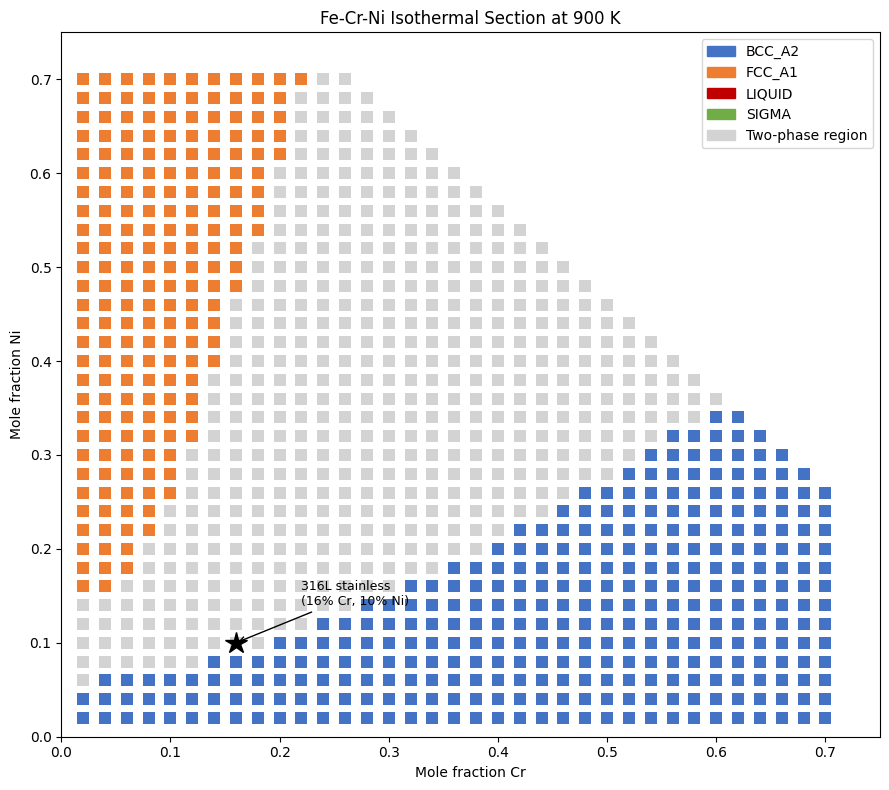

In [ ]:
from pycalphad import Database
import os

db_folder = r"c:\Users\alans\anaconda3\envs\calphad\Lib\site-packages\pycalphad\tests\databases"

dbf4 = Database(db_folder + r"\COST507.tdb")
print(dbf4.elements)
print(list(dbf4.phases.keys()))

print(os.listdir(db_folder))

from pycalphad import Database, equilibrium
import pycalphad.variables as v
import numpy as np
import matplotlib.pyplot as plt

db_folder = r"c:\Users\alans\anaconda3\envs\calphad\Lib\site-packages\pycalphad\tests\databases"

dbf = Database(db_folder + r"\COST507.tdb")

import matplotlib.patches as mpatches

phases_ternary = ['BCC_A2', 'FCC_A1', 'LIQUID', 'SIGMA']
T_ternary = 900  # K — peak sigma formation window

x_cr_range = np.linspace(0.02, 0.70, 35)
x_ni_range = np.linspace(0.02, 0.70, 35)

print("Calculating Fe-Cr-Ni ternary at 900K...")
result_ternary = equilibrium(dbf, ['FE', 'CR', 'NI', 'VA'], phases_ternary,
                             {v.P: 101325,
                              v.T: T_ternary,
                              v.X('CR'): x_cr_range,
                              v.X('NI'): x_ni_range})

colors = {'BCC_A2': '#4472C4', 'FCC_A1': '#ED7D31', 'LIQUID': '#C00000', 'SIGMA': '#70AD47'}

phases_arr = result_ternary.Phase.values[0, 0, 0, :, :, :]  # X_CR, X_NI, vertex
np_arr     = result_ternary.NP.values[0, 0, 0, :, :, :]

fig, ax = plt.subplots(figsize=(9, 8))

for i, x_cr in enumerate(x_cr_range):
    for j, x_ni in enumerate(x_ni_range):
        if x_cr + x_ni >= 0.97:   # skip unphysical compositions
            continue
        stable = [phases_arr[i, j, k] for k in range(3)
                  if phases_arr[i, j, k] != ''
                  and not np.isnan(np_arr[i, j, k])
                  and np_arr[i, j, k] > 0.01]
        if len(stable) == 1:
            color = colors.get(stable[0], 'grey')
        elif len(stable) >= 2:
            color = 'lightgrey'
        else:
            color = 'white'
        ax.plot(x_cr, x_ni, 's', color=color, markersize=9, markeredgewidth=0)

#Now i am doing the same thing i did for binary however because now there is more than 1 composition being added to Fe i need to adjust the loop 
#i and j are the Cr and Ni composition at which the loop goes through the different compositions at a set temperature and maps k phases = 3

# 316L stainless steel target composition
ax.plot(0.16, 0.10, 'k*', markersize=16, zorder=5)
ax.annotate('316L stainless\n(16% Cr, 10% Ni)', xy=(0.16, 0.10),
            xytext=(0.22, 0.14), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='black'))

patches = [mpatches.Patch(color=c, label=p) for p, c in colors.items()]
patches.append(mpatches.Patch(color='lightgrey', label='Two-phase region'))
ax.legend(handles=patches, loc='upper right')
ax.set_xlabel('Mole fraction Cr')
ax.set_ylabel('Mole fraction Ni')
ax.set_title('Fe-Cr-Ni Isothermal Section at 900 K')
ax.set_xlim(0, 0.75)
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.show()

#What we see is that at higher Ni concentrations Fe acts as a FCC stabilizer and at higher Cr concentrations Fe acts as a BCC stabiliser.
#This follows the pattern seen in the two binary graphs and now asks the big quesiton why is the composition the way it is for 316L stainless steel.
#Biggest problem is that there is no sigma phase as expected.
#This is a problem and mostly from a weak database being used and is a lomitation
#This is a problem because the sigma phase is a brittle phase and can cause cracking in the material and it is important to avoid it in the desing of the stainless steel
#This problem means that in production of 316L stainless steel the temperature must be controlled to avoid the formation of the sigma phasegit 

In [ ]:
# Isopleth — fix Ni at 10%, scan T vs X_Cr
# Shows how phase boundaries shift with Ni present — the bridge to CCS mesh design

phases_iso = ['BCC_A2', 'FCC_A1', 'LIQUID', 'SIGMA']

T_range_iso = np.linspace(500, 1600, 60)
x_cr_range_iso = np.linspace(0.02, 0.50, 50)
x_ni_fixed = 0.10  # fixed at 10% Ni — realistic for 316L-type alloy

print("Calculating isopleth (10% Ni fixed)...")
result_iso = equilibrium(dbf, ['FE', 'CR', 'NI', 'VA'], phases_iso,
                         {v.P: 101325,
                          v.T: T_range_iso,
                          v.X('CR'): x_cr_range_iso,
                          v.X('NI'): x_ni_fixed})

colors_iso = {'BCC_A2': '#4472C4', 'FCC_A1': '#ED7D31', 'LIQUID': '#C00000', 'SIGMA': '#70AD47'}

phases_arr_iso = result_iso.Phase.values[0, 0, :, :, 0, :]  # T, X_CR, vertex (X_NI fixed -> index 0)
np_arr_iso     = result_iso.NP.values[0, 0, :, :, 0, :]

fig, ax = plt.subplots(figsize=(10, 8))

for i, T in enumerate(T_range_iso):
    for j, x_cr in enumerate(x_cr_range_iso):
        stable = [phases_arr_iso[i, j, k] for k in range(3)
                  if phases_arr_iso[i, j, k] != ''
                  and not np.isnan(np_arr_iso[i, j, k])
                  and np_arr_iso[i, j, k] > 0.01]
        if len(stable) == 1:
            color = colors_iso.get(stable[0], 'grey')
        elif len(stable) >= 2:
            color = 'lightgrey'
        else:
            color = 'white'
        ax.plot(x_cr, T, 's', color=color, markersize=5, markeredgewidth=0)

# Mark 316L composition (16% Cr, 10% Ni)
ax.axvline(x=0.16, color='black', linestyle='--', linewidth=1.5, label='316L Cr content (16%)')

# Shade the sigma risk fabrication window
ax.axhspan(800, 1100, alpha=0.08, color='red', label='Sigma risk window (800–1100K)')

patches = [mpatches.Patch(color=c, label=p) for p, c in colors_iso.items()]
patches.append(mpatches.Patch(color='lightgrey', label='Two-phase region'))
patches.append(mpatches.Patch(color='red', alpha=0.2, label='Sigma risk window'))
patches.append(plt.Line2D([0],[0], color='black', linestyle='--', label='316L Cr content (16%)'))
ax.legend(handles=patches, loc='upper right')

ax.set_xlabel('Mole fraction Cr')
ax.set_ylabel('Temperature (K)')
ax.set_title('Fe-Cr-Ni Isopleth at 10% Ni — Phase Stability vs Cr Content and Temperature')
plt.tight_layout()
plt.show()

# With 10% Ni fixed, this shows which Cr compositions remain single-phase FCC
# across the fabrication temperature range (800-1100K).
# The safe window, no sigma, single-phase FCC, is the target composition
# for the Fe-Cr-Ni zeolite mesh used in CO2 capture.
# This output feeds directly into RASPA: only compositions in the FCC window
# are worth simulating for CO2 adsorption performance.